In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


from google.colab import files
files.upload()

Saving train.csv to train.csv


{'train.csv': b'battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range\n842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1\n1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2\n563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2\n615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2\n1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1\n1859,0,0.5,1,3,0,22,0.7,164,1,7,1004,1654,1067,17,1,10,1,0,0,1\n1821,0,1.7,0,4,1,10,0.8,139,8,10,381,1018,3220,13,8,18,1,0,1,3\n1954,0,0.5,1,0,0,24,0.8,187,4,0,512,1149,700,16,3,5,1,1,1,0\n1445,1,0.5,0,0,0,53,0.7,174,7,14,386,836,1099,17,1,20,1,0,0,0\n509,1,0.6,1,2,1,9,0.1,93,5,15,1137,1224,513,19,10,12,1,0,0,0\n769,1,2.9,1,0,0,9,0.1,182,5,1,248,874,3946,5,2,7,0,0,0,3\n1520,1,2.2,0,5,1,33,0.5,177,8,18,151,1005,3826,14,9,13,1,1,1,3\n1815,0,2.8,0,2,0,33,0.6,159,4,17,607,748,1482,18,0,2,1,0,0,1\n803,1,

In [2]:
# 1. Data Loading and Exploration:

df = pd.read_csv('train.csv')

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
print(df.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


In [6]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [7]:
# 2. Data Cleaning and Preprocessing:

# Address missing or null values.
# Transform categorical data into numerical format using suitable methods.

In [7]:
print(df.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


In [8]:
# Address missing or null values.
#missing values
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [9]:
df.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [10]:
# Transform categorical data into numerical format using suitable methods.
# Via KNNImputer because One-hot Encoding didn't work

from sklearn.impute import KNNImputer

In [11]:
# # To create a LabelEncoder object
# le = LabelEncoder()

# # Merge the price range columns into a single column
# df['price_range'] = df[['price_range_0', 'price_range_1', 'price_range_2', 'price_range_3']].apply(lambda row: row.idxmax(), axis=1)

# # Check the merged column
# print(df[['price_range_0', 'price_range_1', 'price_range_2', 'price_range_3', 'price_range']].head())

In [12]:
# # now we should apply LabelEncoding to each of the specified columns
# df['price_range'] = le.fit_transform(df['price_range'])
# df.head()

In [13]:
print(df.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


In [14]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [15]:
import numpy as np
from scipy import stats

# Calculate mean, median, and mode for battery_power
mean_battery_power = np.mean(df['battery_power'])
median_battery_power = np.median(df['battery_power'])
mode_battery_power = stats.mode(df['battery_power'])

print(f"Mean: {mean_battery_power}, Median: {median_battery_power}, Mode: {mode_battery_power}")

Mean: 1238.5185, Median: 1226.0, Mode: ModeResult(mode=618, count=6)


In [16]:
#  Variability (Range, Variance, Standard Deviation)
range_battery_power = np.ptp(df['battery_power'])
variance_battery_power = np.var(df['battery_power'])
std_dev_battery_power = np.std(df['battery_power'])

print(f"Range: {range_battery_power}, Variance: {variance_battery_power}, Standard Deviation: {std_dev_battery_power}")

Range: 1497, Variance: 192991.81565774983, Standard Deviation: 439.3083377967573


In [17]:
# Calculate skewness and kurtosis for 'battery_power')
skew_battery_power = stats.skew(df['battery_power'])
kurt_battery_power = stats.kurtosis(df['battery_power'])

print(f"Skewness: {skew_battery_power}, Kurtosis: {kurt_battery_power}")

Skewness: 0.03187454295305568, Kurtosis: -1.224084165725428


In [18]:
# Hypothesis Testing for Statistical Significance

#  t-test between two price ranges (e.g., 'price_range' 0 and 1) for the 'battery_power'
group_0 = df[df['price_range'] == 0]['battery_power']
group_1 = df[df['price_range'] == 1]['battery_power']

t_stat, p_value = stats.ttest_ind(group_0, group_1)

print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -4.166132887458839, P-value: 3.366391080427631e-05


In [19]:
# Investigate feature-target correlations using SciPy.

# Pearson correlation between 'battery_power' and 'price_range'
correlation = stats.pearsonr(df['battery_power'], df['price_range'])[0]

print(f"Correlation between battery power and price range: {correlation}")

Correlation between battery power and price range: 0.20072261211373096


In [20]:
# Apply advanced SciPy statistical functions for deeper insights.
# ANOVA TEST

# First we create separate groups based on price_range
group_0 = df[df['price_range'] == 0]['battery_power']
group_1 = df[df['price_range'] == 1]['battery_power']
group_2 = df[df['price_range'] == 2]['battery_power']
group_3 = df[df['price_range'] == 3]['battery_power']

# To perform ANOVA test
f_stat, p_value = stats.f_oneway(group_0, group_1, group_2, group_3)

print(f"F-statistic: {f_stat}, P-value: {p_value}")

F-statistic: 31.598157539897333, P-value: 5.948688277085545e-20


These values indicate that there's a statistically significant difference in the mean values of battery power among the different price range groups. Since the p-value is much lower than 0.05, we can reject the null hypothesis, meaning at least one price group's mean battery power is significantly different from the others.

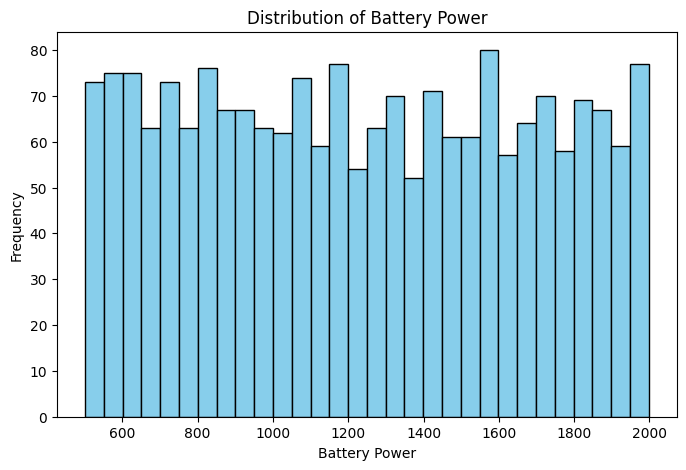

In [21]:
# 4. Data Visualization with Matplotlib (for data distribution and relationship insights)
# histogram (for Data Distribution)
plt.figure(figsize=(8, 5))
plt.hist(df['battery_power'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Battery Power')
plt.ylabel('Frequency')
plt.title('Distribution of Battery Power')
plt.show()

<ipython-input-22-57e0634fe73d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['price_range'], y=df['battery_power'], palette='coolwarm')


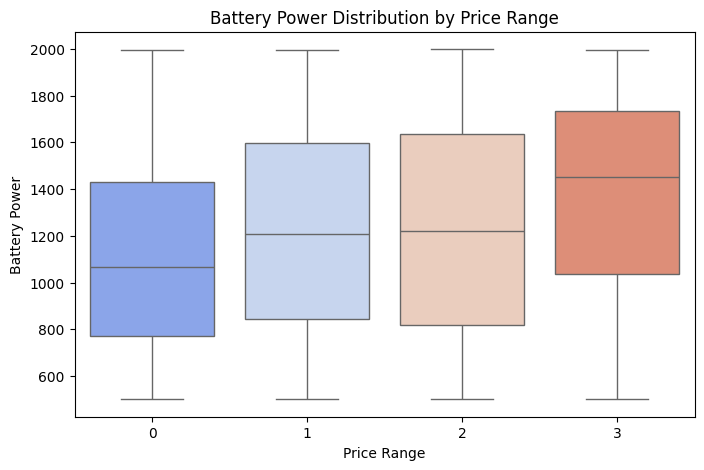

In [22]:
# Box Plot (to Detect Outliers)
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['price_range'], y=df['battery_power'], palette='coolwarm')
plt.xlabel('Price Range')
plt.ylabel('Battery Power')
plt.title('Battery Power Distribution by Price Range')
plt.show()


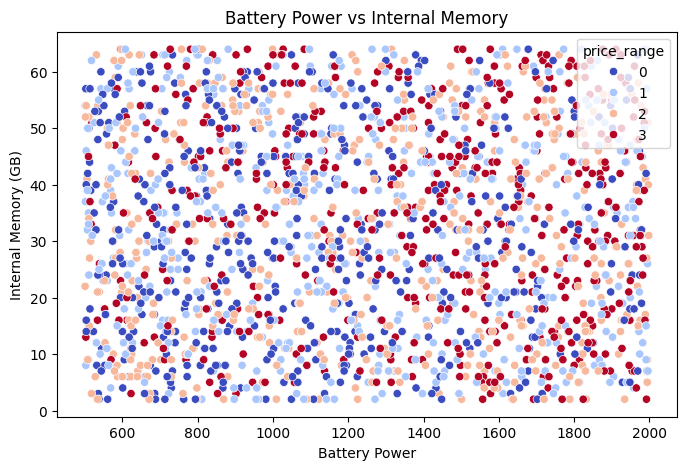

In [23]:
# Scatter Plot (to Show Relationship)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['battery_power'], y=df['int_memory'], hue=df['price_range'], palette='coolwarm')
plt.xlabel('Battery Power')
plt.ylabel('Internal Memory (GB)')
plt.title('Battery Power vs Internal Memory')
plt.show()

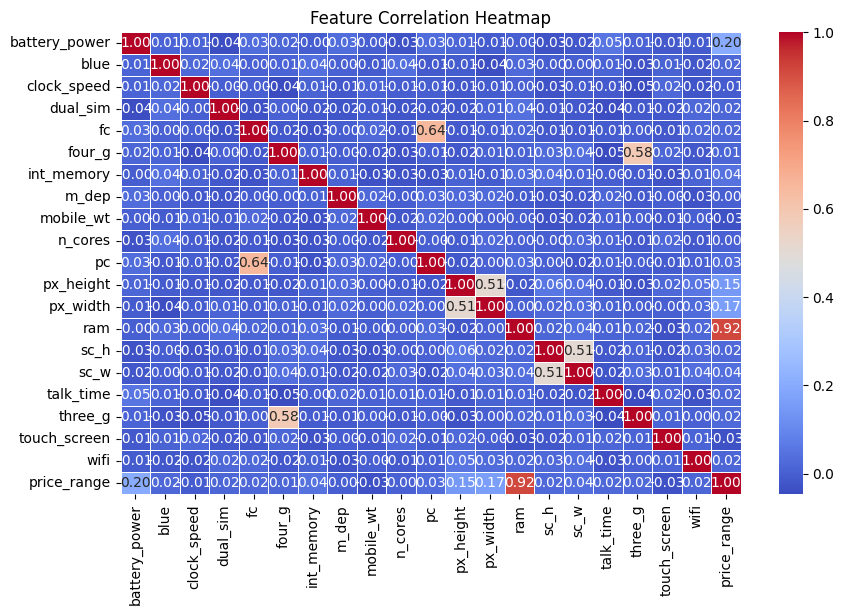

In [24]:
# Heatmap for correlation visualization (to identify which features are strongly correlated)

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

Insight Synthesis and Conclusion

Battery power and internal memory are key determinants of mobile price classification. Higher-priced phones tend to have larger batteries and more storage, as shown in both statistical analysis and visualizations. Features like RAM and pixel resolution also show strong correlations with price.

The ANOVA test confirmed significant differences in features across price ranges, indicating that these attributes play a crucial role in distinguishing phone categories. The heatmap revealed strong positive relationships between price and performance-related features.

Unexpectedly, some budget-friendly phones had high battery power, suggesting that battery capacity alone does not define price. Additionally, categorical features like touchscreen and WiFi may not have a significant impact.

Overall, this analysis provides valuable insights for manufacturers and consumers, helping understand the key specifications influencing mobile pricing.